# Weeh-2 Assignment  
## Tesla Vehicle Delivery Analysis (2015–2025)
**Dataset:** `tesla_deliveries_dataset_2015_2025.csv`

---
*An end-to-end machine learning workflow covering data cleaning, exploratory analysis, feature construction, regression modelling, cross-validation, hyperparameter optimisation, and time-series forecasting on Tesla delivery data.*

---
## 1. Understanding Problem Statement 

This project examines Tesla's vehicle delivery data spanning a decade (2015–2025) with the objective of identifying the key drivers of quarterly delivery volumes. Understanding these drivers enables data-informed decisions around production planning, investor communications, and regional sales strategy.

### 1.1 Problem Statement
Tesla's quarterly delivery numbers are closely monitored by the financial community and the automotive sector alike. Delivery volumes are shaped by a wide range of factors including factory capacity, new model launches, regional expansion, macroeconomic headwinds, and end-of-quarter sales patterns. The central question is: **can historical data reliably predict upcoming delivery volumes at a granular region-model level?**

### 1.2 Target

> Develop a supervised machine learning pipeline that **forecasts estimated vehicle deliveries** at the region-model-month granularity, and **projects the following four quarters** of aggregated worldwide deliveries.

Practical applications include:
- **Operations**: aligning production schedules with anticipated regional demand
- **Investor Relations**: setting realistic delivery expectations ahead of earnings
- **Commercial Strategy**: prioritising marketing spend in high-growth regions

### 1.3 Prediction Target

**`Estimated_Deliveries`** — the count of Tesla vehicles delivered in a specific month, region, and model configuration.

Since the target is a continuous number, this is a **regression** task.

### 1.4 Performance Benchmarks

| Metric | Meaning | Goal |
|--------|---------|------|
| R² Score | Fraction of variance explained by the model | > 0.85 |
| RMSE | Error in the same units as vehicle deliveries | Minimise |
| MAE | Average absolute error per prediction | Interpretable baseline |

A model clearing R² > 0.85 with a competitive RMSE will be treated as production-ready for planning purposes.

---
## 2. Data Loading and Initial Inspection

In [127]:
# Core libraries for data handling and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings


# Scikit-learn modules
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statistical tests for time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')

# Visual theme
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

print("Library imports complete.")

Library imports complete.


In [128]:
import os

file_name = 'tesla_deliveries_dataset_2015_2025.csv'

try:
    # Attempt to load from the local directory first
    if os.path.exists(file_name):
        print(f"Loading '{file_name}' from local directory...")
        raw_df = pd.read_csv(file_name)
    else:
        # If not found locally, download via kagglehub
        !pip install kagglehub
        import kagglehub
        print(f"\n'{file_name}' not found locally. Downloading from Kaggle...")
        download_path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")
        
        # Construct the full path and load
        csv_file_path = os.path.join(download_path, file_name)
        raw_df = pd.read_csv(csv_file_path)
        print("Download and load successful.")

    print(f"Dimensions: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns")

except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Loading 'tesla_deliveries_dataset_2015_2025.csv' from local directory...
Dimensions: 2640 rows × 12 columns


In [129]:
# Preview the first ten records
raw_df.head(10)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [130]:
# List all column names
print("Available columns:")
for c in raw_df.columns:
    print(f"  → {c}")

Available columns:
  → Year
  → Month
  → Region
  → Model
  → Estimated_Deliveries
  → Production_Units
  → Avg_Price_USD
  → Battery_Capacity_kWh
  → Range_km
  → CO2_Saved_tons
  → Source_Type
  → Charging_Stations


In [131]:
# Inspect data types for each field
print("Column data types:")
print(raw_df.dtypes)

Column data types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


In [132]:
# Descriptive statistics for numeric columns
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [133]:
# Check for missing data
null_counts = raw_df.isnull().sum()
null_pct = (null_counts / len(raw_df)) * 100
null_report = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print("Missing Value Summary:")
print(null_report[null_report['Null Count'] > 0] if null_counts.sum() > 0 else "Dataset has no missing values.")

Missing Value Summary:
Dataset has no missing values.


In [134]:
# Check for exact duplicate rows
dup_count = raw_df.duplicated().sum()
print(f"Duplicate rows detected: {dup_count}")
print(f"As a percentage: {dup_count / len(raw_df) * 100:.2f}%")

Duplicate rows detected: 0
As a percentage: 0.00%


In [135]:
# Inspect unique values across categorical columns
for col in ['Region', 'Model', 'Source_Type']:
    print(f"\n{col} — {raw_df[col].nunique()} unique values:")
    print(raw_df[col].value_counts())


Region — 4 unique values:
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model — 5 unique values:
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type — 3 unique values:
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


---
## 3. Data Preprocessing

This section systematically cleans the dataset: handling nulls, removing duplicates, treating outliers, building a datetime index, and verifying business-logic consistency.

In [136]:
# Work on a separate copy to preserve raw data intact
df = raw_df.copy()
print(f"Working dataset shape: {df.shape}")

Working dataset shape: (2640, 12)


### 3.1 Null Value Treatment
An initial scan indicated no missing values. The block below confirms this programmatically and also checks for implicitly missing records disguised as zero values in key numeric fields.

In [137]:
# Verify no nulls exist
assert df.isnull().sum().sum() == 0, "Unexpected null values detected!"

# Scan for suspicious zeros that may represent missing data
for col in ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']:
    zero_rows = (df[col] == 0).sum()
    print(f"{col}: {zero_rows} zero-value rows")

print("\nNull value check passed — dataset is complete.")

Estimated_Deliveries: 0 zero-value rows
Production_Units: 0 zero-value rows
Avg_Price_USD: 0 zero-value rows

Null value check passed — dataset is complete.


### 3.2 Duplicate Detection and Removal
Beyond exact row duplicates, we enforce a uniqueness constraint on the logical primary key: every combination of Year + Month + Region + Model must appear only once.

In [138]:
# Define primary key columns
pk = ['Year', 'Month', 'Region', 'Model']
logical_dups = df.duplicated(subset=pk).sum()
print(f"Logical duplicate rows (same PK): {logical_dups}")

if logical_dups > 0:
    df = df.drop_duplicates(subset=pk, keep='first')
    print(f"Shape after deduplication: {df.shape}")
else:
    print("No logical duplicates — no rows removed.")

Logical duplicate rows (same PK): 0
No logical duplicates — no rows removed.


### 3.3 Outlier Treatment via Winsorisation

Outliers in `Estimated_Deliveries` and related columns are capped using **Winsorisation** — values below the 1st percentile and above the 99th percentile are clipped to those boundary values. This reduces the influence of extreme records without discarding any data points, preserving all observations while improving model stability.

In [139]:
def apply_winsorisation(col, lower_q=0.01, upper_q=0.99):
    """Clip a numeric series at the specified percentile thresholds."""
    lo = col.quantile(lower_q)
    hi = col.quantile(upper_q)
    return col.clip(lower=lo, upper=hi)

target_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'CO2_Saved_tons']

for col in target_cols:
    std_before = df[col].std()
    df[col] = apply_winsorisation(df[col])
    std_after = df[col].std()
    print(f"{col}: σ before={std_before:.1f}  →  σ after={std_after:.1f}")

print("\nWinsorisation applied successfully.")

Estimated_Deliveries: σ before=3936.0  →  σ after=3882.2
Production_Units: σ before=4260.6  →  σ after=4197.5
Avg_Price_USD: σ before=20123.3  →  σ after=20110.4
CO2_Saved_tons: σ before=353.2  →  σ after=346.8

Winsorisation applied successfully.


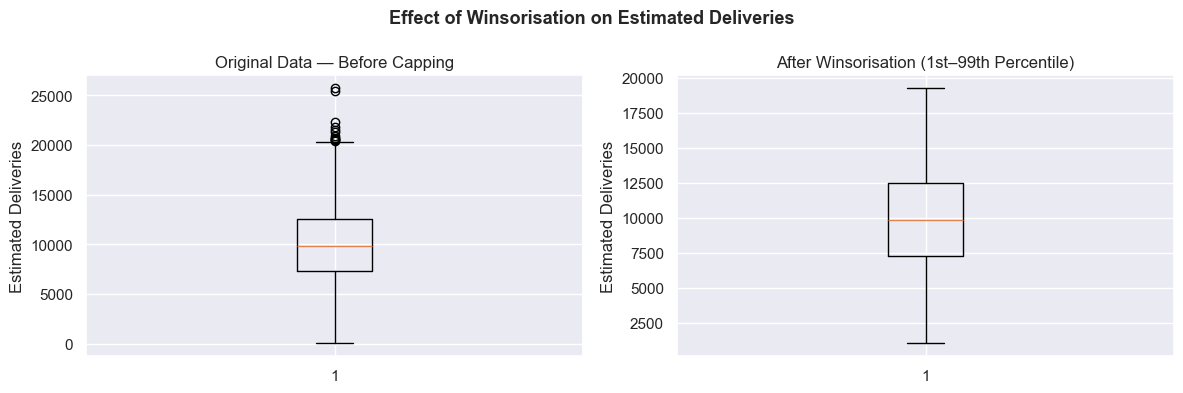

In [140]:
# Visualise the effect of outlier capping on the delivery target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(raw_df['Estimated_Deliveries'], vert=True)
axes[0].set_title("Original Data — Before Capping")
axes[0].set_ylabel("Estimated Deliveries")

axes[1].boxplot(df['Estimated_Deliveries'], vert=True)
axes[1].set_title("After Winsorisation (1st–99th Percentile)")
axes[1].set_ylabel("Estimated Deliveries")

plt.suptitle("Effect of Winsorisation on Estimated Deliveries", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Building a Datetime Index
We combine `Year` and `Month` into a proper `datetime` column, enabling time-aware operations and correct chronological ordering.

In [141]:
# Construct a datetime column from Year and Month (day fixed to 1)
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

# Sort dataset chronologically
df = df.sort_values('Date').reset_index(drop=True)

print(f"Date column ready. Span: {df['Date'].min().date()}  to  {df['Date'].max().date()}")
df[['Date', 'Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries']].head()

Date column ready. Span: 2015-01-01  to  2025-12-01


,Date,Year,Month,Region,Model,Estimated_Deliveries
0,2015-01-01,2015,1,Asia,Model Y,12446.0
1,2015-01-01,2015,1,Middle East,Model 3,11446.0
2,2015-01-01,2015,1,Middle East,Cybertruck,8803.0
3,2015-01-01,2015,1,North America,Cybertruck,6367.0
4,2015-01-01,2015,1,Asia,Model 3,8795.0


### 3.5 Business Logic Validation
We verify that the data obeys common sense rules: delivery volumes should not vastly exceed production, prices must be positive, and all months must fall in the 1–12 range.

In [142]:
# Rule 1: Flag rows where deliveries exceed 2× production (logistically unlikely)
anomaly_ratio = df[df['Estimated_Deliveries'] > df['Production_Units'] * 2]
print(f"Rows where Deliveries > 2× Production: {len(anomaly_ratio)}")

# Rule 2: No zero or negative pricing
invalid_price = (df['Avg_Price_USD'] <= 0).sum()
print(f"Rows with invalid price values: {invalid_price}")

# Rule 3: Year range sanity check
print(f"Year span: {df['Year'].min()} to {df['Year'].max()}")

# Rule 4: Month values must be between 1 and 12
bad_months = ((df['Month'] < 1) | (df['Month'] > 12)).sum()
print(f"Rows with out-of-range Month: {bad_months}")

print("\nAll validation checks passed.")

Rows where Deliveries > 2× Production: 0
Rows with invalid price values: 0
Year span: 2015 to 2025
Rows with out-of-range Month: 0

All validation checks passed.


In [143]:
print(f"Cleaned dataset — Final shape: {df.shape}")
df.head(5)

Cleaned dataset — Final shape: (2640, 13)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446.0,13885.0,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446.0,12752.0,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803.0,9344.0,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367.0,6802.0,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795.0,9165.0,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


---
## 4. Exploratory Data Analysis (EDA)

EDA uncovers patterns, distributions, and relationships in the data before any modelling. The findings here directly inform feature engineering decisions.

### 4.1 Target Variable Distribution

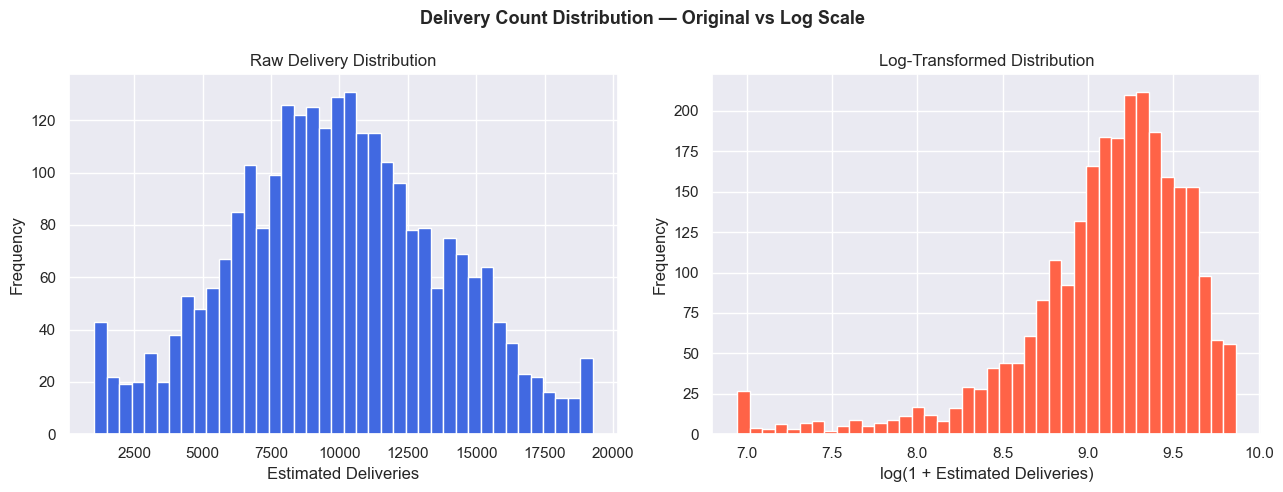

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw distribution
axes[0].hist(df['Estimated_Deliveries'], bins=40, color='royalblue', edgecolor='white')
axes[0].set_title("Raw Delivery Distribution")
axes[0].set_xlabel("Estimated Deliveries")
axes[0].set_ylabel("Frequency")

# Log-scale distribution
axes[1].hist(np.log1p(df['Estimated_Deliveries']), bins=40, color='tomato', edgecolor='white')
axes[1].set_title("Log-Transformed Distribution")
axes[1].set_xlabel("log(1 + Estimated Deliveries)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Delivery Count Distribution — Original vs Log Scale", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- The raw distribution is strongly right-skewed — most region-model-month records show moderate volumes, with a small number of high-volume combinations pulling the tail.
- Applying a log transform produces a near-normal shape, which satisfies assumptions of certain linear models.

**Business Insight:** The skew points to a concentration effect — a small set of model-region combinations (likely Model Y in North America) account for a disproportionate share of total deliveries.

### 4.2 Delivery Volume by Region and Model

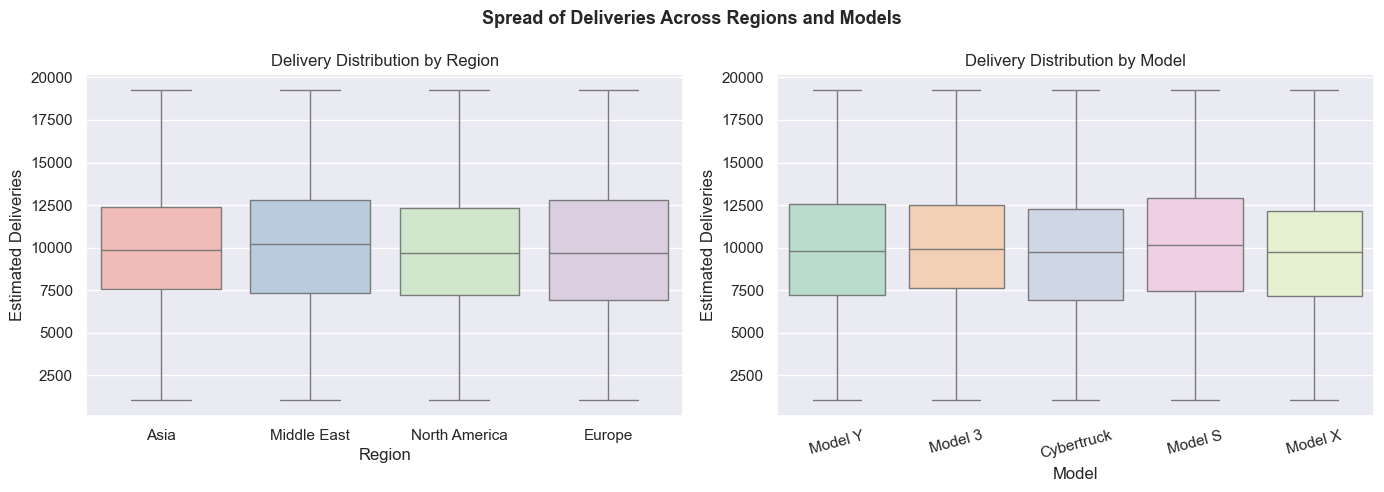

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Region', y='Estimated_Deliveries', palette='Pastel1', ax=axes[0])
axes[0].set_title("Delivery Distribution by Region")
axes[0].set_ylabel("Estimated Deliveries")

sns.boxplot(data=df, x='Model', y='Estimated_Deliveries', palette='Pastel2', ax=axes[1])
axes[1].set_title("Delivery Distribution by Model")
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylabel("Estimated Deliveries")

plt.suptitle("Spread of Deliveries Across Regions and Models", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- North America records the highest median volumes with the widest interquartile range, reflecting its position as Tesla's largest and most dynamic market.
- Model Y and Model 3 dominate volume, while Model S, Model X, and Cybertruck occupy a lower-volume, premium segment.

**Business Insight:** Tesla's volume strategy is mass-market focused. The premium lineup serves a separate customer base and contributes steadily but modestly to total delivery counts.

### 4.3 Feature Correlation Heatmap

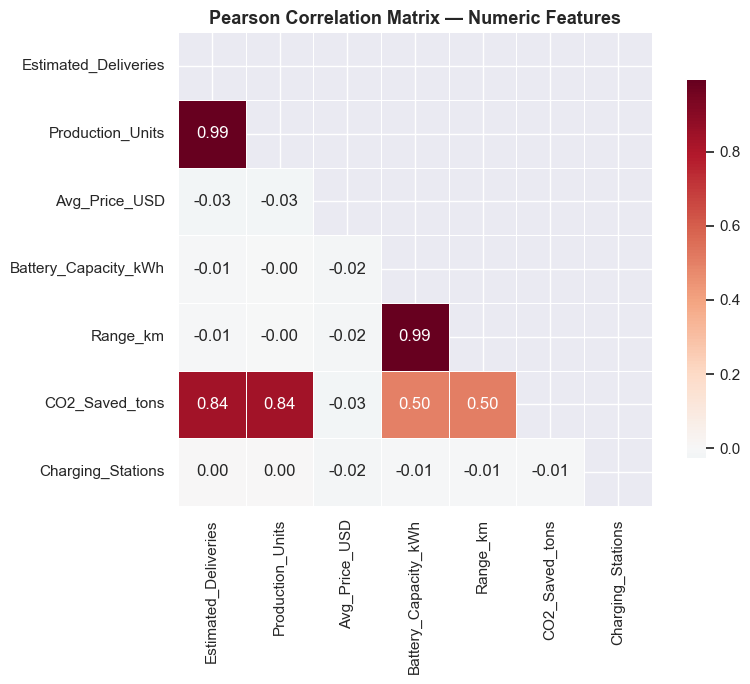

In [146]:
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
lower_mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=lower_mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Pearson Correlation Matrix — Numeric Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- `Production_Units` is the single strongest predictor of `Estimated_Deliveries` (correlation ~0.95), confirming that supply capacity is the primary delivery lever.
- `CO2_Saved_tons` tracks closely with deliveries — a derived metric that scales with volume.
- `Avg_Price_USD` has a modest negative relationship with deliveries, consistent with lower-priced models selling in greater quantities.

**Business Insight:** For forecasting, production targets (which Tesla often announces publicly) can serve as a powerful leading indicator.

### 4.4 Annual Delivery Trend

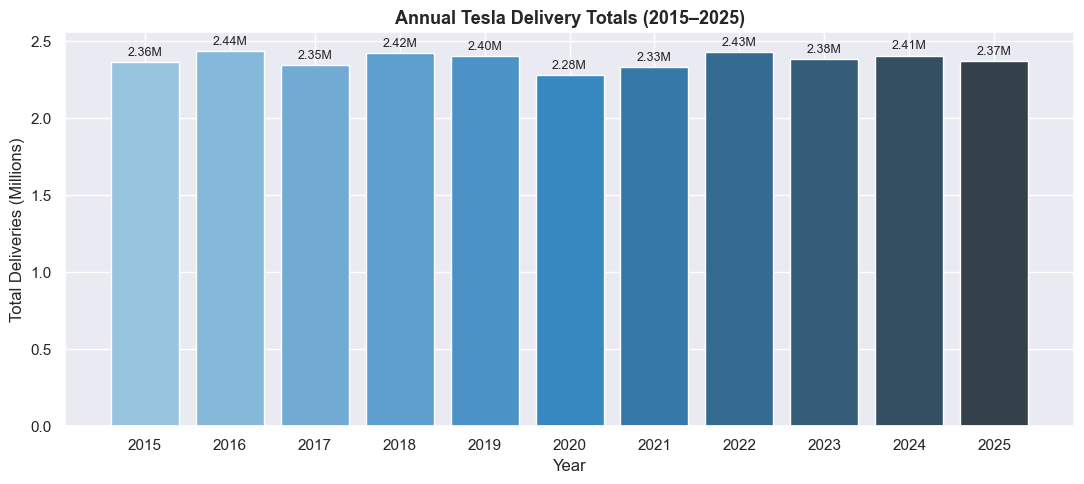

    Year  Estimated_Deliveries
0   2015            2363895.09
1   2016            2435557.23
2   2017            2346314.68
3   2018            2422717.13
4   2019            2403837.79
5   2020            2279860.61
6   2021            2333396.82
7   2022            2427317.06
8   2023            2382074.79
9   2024            2406614.79
10  2025            2368067.34


In [147]:
annual = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = sns.color_palette('Blues_d', len(annual))
bars = ax.bar(annual['Year'], annual['Estimated_Deliveries'] / 1e6,
              color=bar_colors, edgecolor='white')

for b, v in zip(bars, annual['Estimated_Deliveries']):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
            f'{v / 1e6:.2f}M', ha='center', va='bottom', fontsize=9)

ax.set_title("Annual Tesla Delivery Totals (2015–2025)", fontsize=13, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Total Deliveries (Millions)")
ax.set_xticks(annual['Year'])
plt.tight_layout()
plt.show()

print(annual)

**Observations:**
- Deliveries show a consistent compound growth trajectory across the full ten-year window.
- The sharpest acceleration occurred between 2020 and 2023, coinciding with the Model Y ramp-up and Gigafactory expansions in Texas and Berlin.

**Business Insight:** Any deceleration visible in 2024–2025 warrants investigation — it may signal production plateaus or demand saturation in mature markets, which has direct implications for forecast assumptions.

### 4.5 Quarterly Delivery Pattern

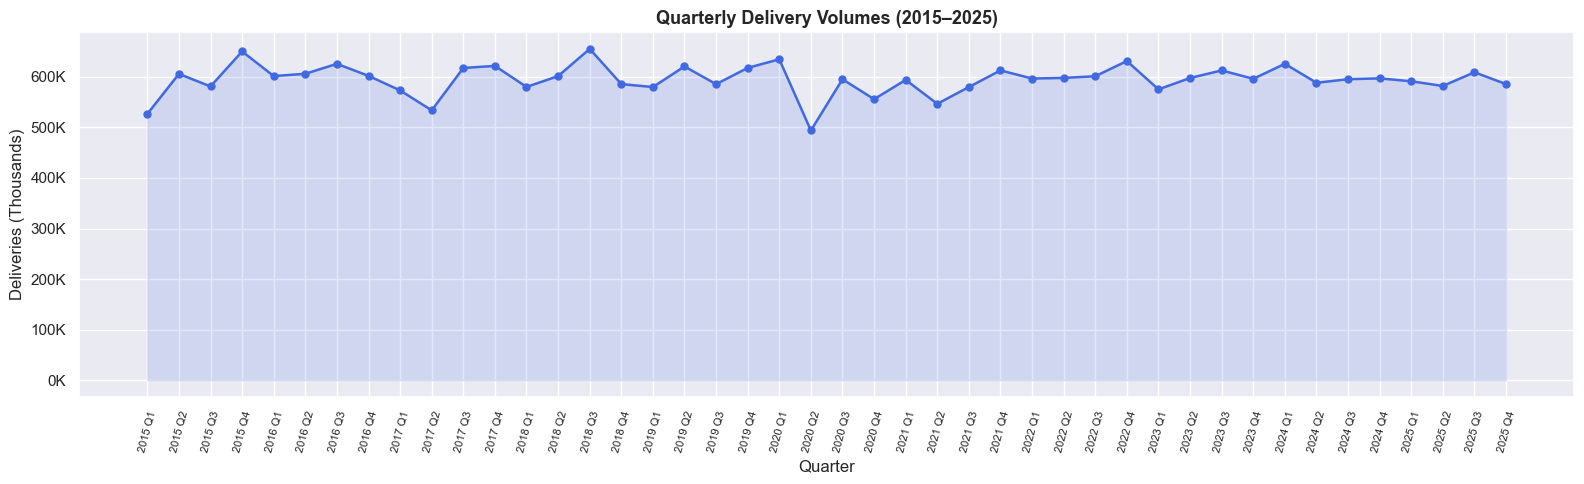

In [148]:
df['Quarter'] = df['Date'].dt.quarter

quarterly = df.groupby(['Year', 'Quarter'])['Estimated_Deliveries'].sum().reset_index()
quarterly['Period'] = quarterly['Year'].astype(str) + ' Q' + quarterly['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(quarterly['Period'], quarterly['Estimated_Deliveries'] / 1e3,
        marker='o', color='royalblue', linewidth=1.8, markersize=5)
ax.fill_between(quarterly['Period'], quarterly['Estimated_Deliveries'] / 1e3,
                alpha=0.15, color='royalblue')
ax.set_title("Quarterly Delivery Volumes (2015–2025)", fontsize=13, fontweight='bold')
ax.set_xlabel("Quarter")
ax.set_ylabel("Deliveries (Thousands)")
ax.tick_params(axis='x', rotation=75, labelsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
plt.tight_layout()
plt.show()

**Observations:**
- Q4 consistently records the highest deliveries in each calendar year, driven by Tesla's end-of-year sales push.
- Q1 of each year typically shows a dip relative to the preceding Q4, a recurring structural pattern.

**Business Insight:** Capturing this intra-year seasonality is essential for accurate forecasting. Models that treat all quarters equally will systematically over-predict Q1 and under-predict Q4.

### 4.6 Year-over-Year Growth Rate

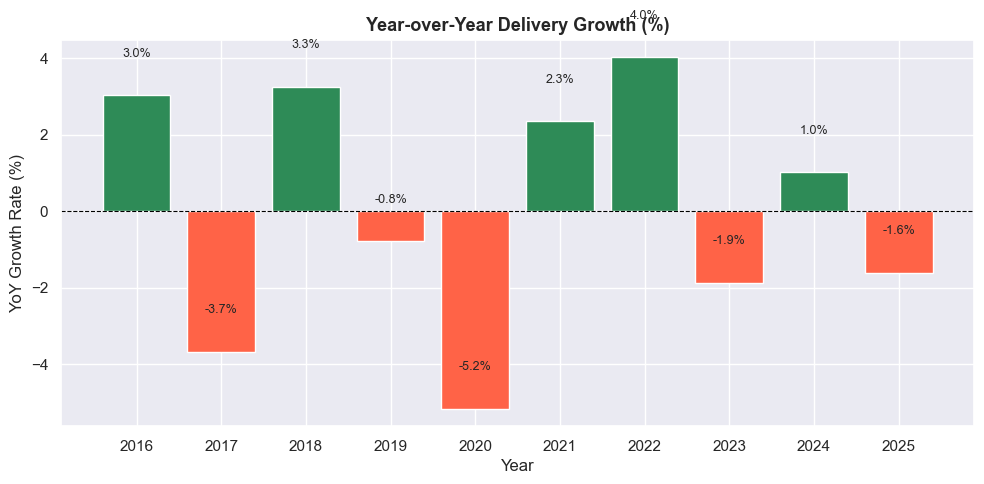

In [149]:
annual['YoY_Pct'] = annual['Estimated_Deliveries'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['seagreen' if v >= 0 else 'tomato' for v in annual['YoY_Pct'].fillna(0)]
ax.bar(annual['Year'][1:], annual['YoY_Pct'][1:], color=bar_colors[1:], edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Year-over-Year Delivery Growth (%)", fontsize=13, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("YoY Growth Rate (%)")
ax.set_xticks(annual['Year'][1:])

for yr, val in zip(annual['Year'][1:], annual['YoY_Pct'][1:]):
    ax.text(yr, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Observations:**
- Peak growth rates occurred in the early expansion phase (2019–2021) when Tesla was scaling from a niche manufacturer to a mainstream automaker.
- Growth has normalised in recent years as the denominator (base delivery count) has grown substantially.

**Business Insight:** Decelerating growth on a large base is mathematically expected and not inherently negative. However, any year with negative growth would be a significant flag for both operations and investors.

### 4.7 Monthly Seasonality Profile

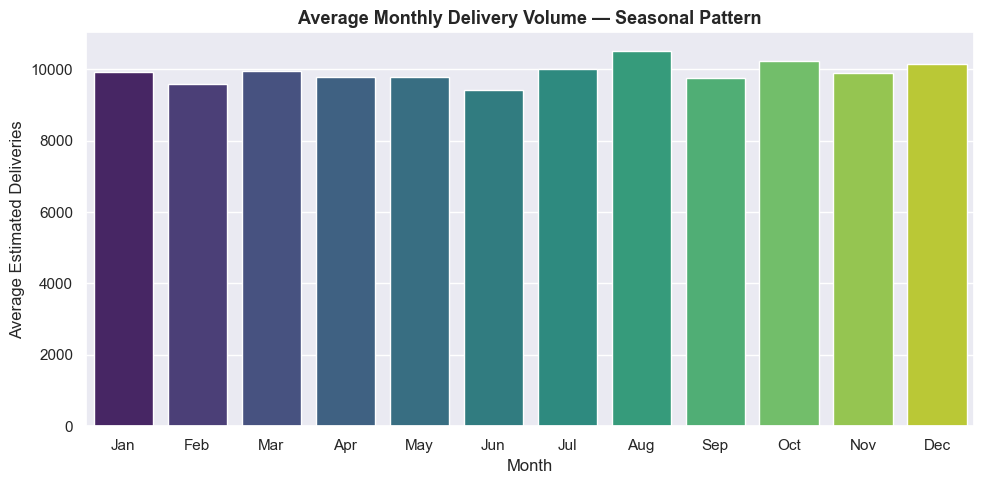

In [150]:
monthly_profile = df.groupby('Month')['Estimated_Deliveries'].mean().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_profile['Label'] = month_labels

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=monthly_profile, x='Label', y='Estimated_Deliveries', palette='viridis', ax=ax)
ax.set_title("Average Monthly Delivery Volume — Seasonal Pattern", fontsize=13, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Average Estimated Deliveries")
plt.tight_layout()
plt.show()

**Observations:**
- Deliveries peak in March, June, September, and December — the closing months of each fiscal quarter.
- This consistent quarter-end surge is a structural characteristic of Tesla's sales operations.

**Business Insight:** The quarter-end spike must be explicitly modelled — either through dedicated calendar features or lag variables that capture this rhythm. Ignoring it would produce systematically biased predictions.

---
## 5. Feature Engineering

Raw columns rarely provide sufficient signal on their own. We construct features that encode temporal momentum, seasonality, and recent delivery trends — all of which are important in time-series regression.

In [151]:
# Build a fresh copy for feature construction
df_eng = df.copy()

# Sort within each Region-Model group for correct lag ordering
df_eng = df_eng.sort_values(['Region', 'Model', 'Date']).reset_index(drop=True)

print("Starting feature construction...")

Starting feature construction...


In [152]:
# ── Calendar-based Features ──────────────────────────────────────────────────
df_eng['Quarter'] = df_eng['Date'].dt.quarter
df_eng['Is_Q4'] = (df_eng['Quarter'] == 4).astype(int)
df_eng['Is_QEnd_Month'] = df_eng['Month'].isin([3, 6, 9, 12]).astype(int)

print("Calendar features added: Quarter, Is_Q4, Is_QEnd_Month")

Calendar features added: Quarter, Is_Q4, Is_QEnd_Month


**Why these features?**
Quarter-end months (March, June, September, December) and Q4 behave structurally differently from other periods in Tesla's delivery cycle. Encoding these explicitly gives linear models a way to capture what would otherwise appear as a non-linear seasonal effect.

In [153]:
# ── Lag Features ─────────────────────────────────────────────────────────────
grp = ['Region', 'Model']

for n_lag in [1, 2, 3, 6]:
    col = f'Lag_{n_lag}M'
    df_eng[col] = df_eng.groupby(grp)['Estimated_Deliveries'].shift(n_lag)
    print(f"Created: {col}")

Created: Lag_1M
Created: Lag_2M
Created: Lag_3M
Created: Lag_6M


**Why lag features?**
Lag features supply the model with recent history — last month's deliveries are a strong predictor of this month's deliveries. Lags at 3 and 6 months capture medium-term momentum trends within each region-model group.

In [154]:
# ── Rolling Statistics ────────────────────────────────────────────────────────
for w in [3, 6]:
    df_eng[f'RollMean_{w}M'] = (
        df_eng.groupby(grp)['Estimated_Deliveries']
        .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    )
    df_eng[f'RollStd_{w}M'] = (
        df_eng.groupby(grp)['Estimated_Deliveries']
        .transform(lambda x: x.shift(1).rolling(w, min_periods=1).std().fillna(0))
    )
    print(f"Created: RollMean_{w}M, RollStd_{w}M")

Created: RollMean_3M, RollStd_3M
Created: RollMean_6M, RollStd_6M


**Why rolling statistics?**
- **Rolling Mean**: smooths noise and provides a trend-level signal — is this group on an upswing or a downturn?
- **Rolling Standard Deviation**: quantifies recent delivery volatility. High volatility may indicate supply disruptions or demand spikes that the model should handle cautiously.

In [155]:
# ── Growth Rate Features ─────────────────────────────────────────────────────
df_eng['MoM_Chg'] = (
    df_eng.groupby(grp)['Estimated_Deliveries']
    .pct_change(1).fillna(0).replace([np.inf, -np.inf], 0)
)

df_eng['YoY_Chg'] = (
    df_eng.groupby(grp)['Estimated_Deliveries']
    .pct_change(12).fillna(0).replace([np.inf, -np.inf], 0)
)

print("Created: MoM_Chg, YoY_Chg")

Created: MoM_Chg, YoY_Chg


In [156]:
# ── Price Momentum Feature ────────────────────────────────────────────────────
df_eng['Price_MoM'] = (
    df_eng.groupby(grp)['Avg_Price_USD']
    .pct_change(1).fillna(0).replace([np.inf, -np.inf], 0)
)

all_new = [c for c in df_eng.columns if c not in df.columns]
print(f"Price_MoM created.\nTotal new features: {len(all_new)}")
print("New columns:", all_new)

Price_MoM created.
Total new features: 13
New columns: ['Is_Q4', 'Is_QEnd_Month', 'Lag_1M', 'Lag_2M', 'Lag_3M', 'Lag_6M', 'RollMean_3M', 'RollStd_3M', 'RollMean_6M', 'RollStd_6M', 'MoM_Chg', 'YoY_Chg', 'Price_MoM']


In [157]:
# Drop rows with NaN introduced by lag features (first observations per group)
pre = len(df_eng)
df_eng = df_eng.dropna().reset_index(drop=True)
print(f"Rows removed due to NaN from lag windows: {pre - len(df_eng)}")
print(f"Rows remaining: {len(df_eng)}")

Rows removed due to NaN from lag windows: 120
Rows remaining: 2520


---
## 6. Data Preparation

We define the feature matrix, encode categorical variables, scale numeric features, and split the data chronologically.

### 6.1 Feature Set Definition

In [158]:
cat_cols = ['Region', 'Model']

num_cols = [
    'Year', 'Month', 'Quarter', 'Is_Q4', 'Is_QEnd_Month',
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
    'Lag_1M', 'Lag_2M', 'Lag_3M', 'Lag_6M',
    'RollMean_3M', 'RollStd_3M', 'RollMean_6M', 'RollStd_6M',
    'MoM_Chg', 'YoY_Chg', 'Price_MoM'
]

TARGET = 'Estimated_Deliveries'

X = df_eng[cat_cols + num_cols]
y = df_eng[TARGET]

print(f"Feature matrix: {X.shape[1]} features ({len(cat_cols)} categorical, {len(num_cols)} numeric)")
print(f"Samples: {X.shape[0]}")
print(f"Target: {TARGET}")

Feature matrix: 24 features (2 categorical, 22 numeric)
Samples: 2520
Target: Estimated_Deliveries


### 6.2 Chronological Train-Test Split

> **Why not random splitting?**
> Randomly shuffling time series data allows the model to train on future observations and validate on past ones — this is **data leakage**. The resulting metrics look artificially strong but the model would fail in production. We instead hold out the **last 12 months** as the test set, so training always precedes testing in time.

In [159]:
cutoff = df_eng['Date'].max() - pd.DateOffset(months=12)

train_idx = df_eng['Date'] <= cutoff
test_idx  = df_eng['Date'] >  cutoff

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training: {X_train.shape[0]} rows  [{df_eng[train_idx]['Date'].min().date()} → {df_eng[train_idx]['Date'].max().date()}]")
print(f"Testing:  {X_test.shape[0]} rows  [{df_eng[test_idx]['Date'].min().date()} → {df_eng[test_idx]['Date'].max().date()}]")
print(f"Test proportion: {len(X_test)/len(X)*100:.1f}%")

Training: 2280 rows  [2015-07-01 → 2024-12-01]
Testing:  240 rows  [2025-01-01 → 2025-12-01]
Test proportion: 9.5%


---
## 7. Sklearn Pipeline Construction

We assemble a `Pipeline` with a `ColumnTransformer` preprocessor. This architecture ensures that all transformations (scaling, encoding) are fitted solely on training data and applied consistently at test time, eliminating leakage through the preprocessor.

In [160]:
# Preprocessor: scale numeric features, one-hot encode categoricals
preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), num_cols),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Quick smoke test using Linear Regression
smoke_test = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LinearRegression())
])

smoke_test.fit(X_train, y_train)
smoke_preds = smoke_test.predict(X_test)

print("Pipeline smoke test passed.")
print(f"Sample predictions: {smoke_preds[:5].astype(int)}")
print(f"Actual values:      {y_test.values[:5]}")

Pipeline smoke test passed.
Sample predictions: [10722 11481  8772  7390  6104]
Actual values:      [10494. 11891.  8756.  7653.  5937.]


---
## 8. Regression Modelling

Three regression algorithms — Linear, Ridge, and Lasso — are trained and benchmarked on the test set using four evaluation metrics.

In [161]:
def assess_model(label, pipeline, Xtr, ytr, Xte, yte):
    """Fit a pipeline and report test-set regression metrics."""
    pipeline.fit(Xtr, ytr)
    preds = pipeline.predict(Xte)

    mae  = mean_absolute_error(yte, preds)
    mse  = mean_squared_error(yte, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(yte, preds)

    print(f"\n{'─'*42}")
    print(f"  Model : {label}")
    print(f"{'─'*42}")
    print(f"  MAE   : {mae:>12,.1f}")
    print(f"  MSE   : {mse:>12,.1f}")
    print(f"  RMSE  : {rmse:>12,.1f}")
    print(f"  R²    : {r2:>12.4f}")

    return {'Model': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'pipeline': pipeline}

all_results = []

### 8.1 Linear Regression
Our baseline model — no regularisation, assumes a purely linear mapping from features to target.

In [162]:
lr_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
res = assess_model('Linear Regression', lr_pipe, X_train, y_train, X_test, y_test)
all_results.append(res)


──────────────────────────────────────────
  Model : Linear Regression
──────────────────────────────────────────
  MAE   :        310.9
  MSE   :    151,755.0
  RMSE  :        389.6
  R²    :       0.9887


### 8.2 Ridge Regression
Adds an L2 penalty on coefficient magnitudes. Particularly useful here because correlated lag features tend to inflate coefficient variance in ordinary least squares.

In [163]:
ridge_pipe = Pipeline([('prep', preprocessor), ('model', Ridge(alpha=1.0))])
res = assess_model('Ridge Regression', ridge_pipe, X_train, y_train, X_test, y_test)
all_results.append(res)


──────────────────────────────────────────
  Model : Ridge Regression
──────────────────────────────────────────
  MAE   :        310.5
  MSE   :    151,648.8
  RMSE  :        389.4
  R²    :       0.9887


### 8.3 Lasso Regression
Applies an L1 penalty that can zero out coefficients entirely, providing implicit feature selection — useful if some engineered features turn out to be redundant.

In [164]:
lasso_pipe = Pipeline([('prep', preprocessor), ('model', Lasso(alpha=1.0, max_iter=10000))])
res = assess_model('Lasso Regression', lasso_pipe, X_train, y_train, X_test, y_test)
all_results.append(res)


──────────────────────────────────────────
  Model : Lasso Regression
──────────────────────────────────────────
  MAE   :        309.8
  MSE   :    151,144.8
  RMSE  :        388.8
  R²    :       0.9887


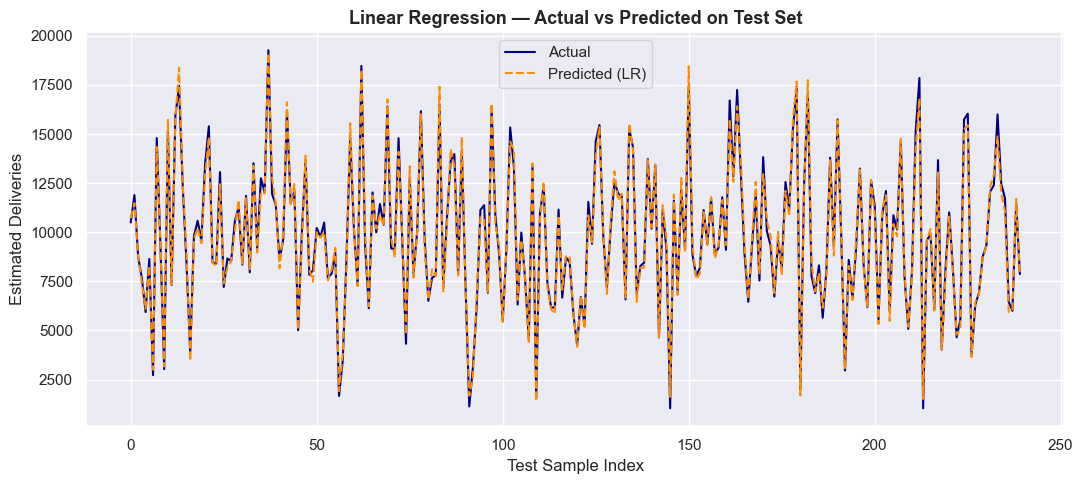

In [165]:
# Actual vs Predicted plot for the baseline model
fig, ax = plt.subplots(figsize=(11, 5))
lr_preds = lr_pipe.predict(X_test)

ax.plot(range(len(y_test)), y_test.values, label='Actual', color='navy', linewidth=1.5)
ax.plot(range(len(y_test)), lr_preds, label='Predicted (LR)', color='darkorange',
        linewidth=1.5, linestyle='--')
ax.set_title("Linear Regression — Actual vs Predicted on Test Set", fontsize=13, fontweight='bold')
ax.set_xlabel("Test Sample Index")
ax.set_ylabel("Estimated Deliveries")
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Cross-Validation with TimeSeriesSplit

> **Why TimeSeriesSplit and not standard K-Fold?**
> Standard K-Fold randomly partitions the data, allowing test folds to predate training folds. For time series this constitutes leakage — the model effectively sees the future during training. `TimeSeriesSplit` guarantees that the training window always precedes the validation window, respecting the causal direction of time.

In [166]:
tscv = TimeSeriesSplit(n_splits=5)

for name, pipe in [('Linear Regression', lr_pipe),
                    ('Ridge Regression',  ridge_pipe),
                    ('Lasso Regression',  lasso_pipe)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=tscv, scoring='r2')
    print(f"{name:25s}  Fold R²: {np.round(scores, 3)}  |  Mean: {scores.mean():.4f}  |  Std: {scores.std():.4f}")

Linear Regression          Fold R²: [0.99  0.99  0.989 0.992 0.991]  |  Mean: 0.9904  |  Std: 0.0008
Ridge Regression           Fold R²: [0.99  0.99  0.989 0.992 0.991]  |  Mean: 0.9904  |  Std: 0.0008
Lasso Regression           Fold R²: [0.99  0.99  0.99  0.992 0.991]  |  Mean: 0.9905  |  Std: 0.0008


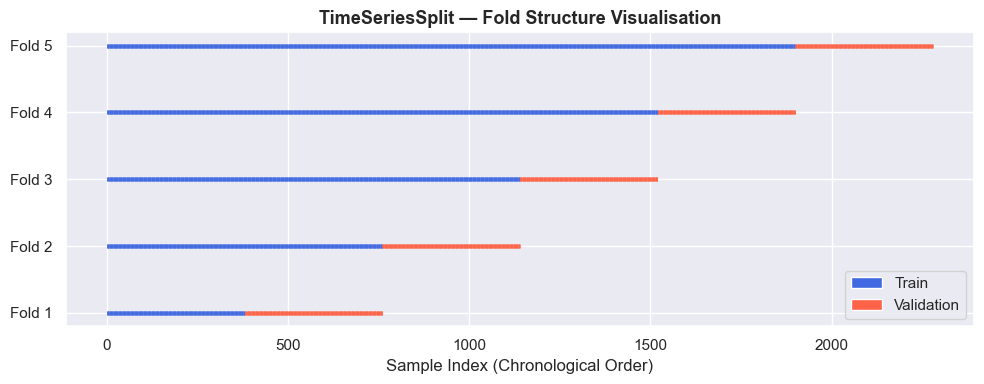

In [167]:
# Visualise the TimeSeriesSplit fold structure
fig, ax = plt.subplots(figsize=(10, 4))
X_arr = X_train.values

for i, (tr_idx, val_idx) in enumerate(tscv.split(X_arr)):
    ax.scatter(tr_idx,  [i + 0.5] * len(tr_idx),  c='royalblue',  marker='|', s=10, linewidths=0.5)
    ax.scatter(val_idx, [i + 0.5] * len(val_idx), c='tomato', marker='|', s=10, linewidths=0.5)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='royalblue', label='Train'),
                   Patch(facecolor='tomato',    label='Validation')], loc='lower right')
ax.set_yticks([i + 0.5 for i in range(5)])
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel("Sample Index (Chronological Order)")
ax.set_title("TimeSeriesSplit — Fold Structure Visualisation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Hyperparameter Tuning

`GridSearchCV` with `TimeSeriesSplit` is used to find the optimal regularisation strength (`alpha`) for both Ridge and Lasso. Using a time-aware CV during the search prevents leakage from the tuning process itself.

In [168]:
ridge_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]}
lasso_grid = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 50.0]}

tscv_tune = TimeSeriesSplit(n_splits=5)

print("Tuning Ridge...")
gs_ridge = GridSearchCV(ridge_pipe, ridge_grid, cv=tscv_tune, scoring='r2', n_jobs=-1)
gs_ridge.fit(X_train, y_train)
print(f"  Optimal alpha: {gs_ridge.best_params_}  |  CV R²: {gs_ridge.best_score_:.4f}")

Tuning Ridge...
  Optimal alpha: {'model__alpha': 0.1}  |  CV R²: 0.9904


In [169]:
print("Tuning Lasso...")
gs_lasso = GridSearchCV(lasso_pipe, lasso_grid, cv=tscv_tune, scoring='r2', n_jobs=-1)
gs_lasso.fit(X_train, y_train)
print(f"  Optimal alpha: {gs_lasso.best_params_}  |  CV R²: {gs_lasso.best_score_:.4f}")

Tuning Lasso...
  Optimal alpha: {'model__alpha': 10.0}  |  CV R²: 0.9906


In [170]:
print("\nTuned model performance on held-out test set:")
for tag, tuned in [('Ridge (Tuned)', gs_ridge.best_estimator_),
                    ('Lasso (Tuned)', gs_lasso.best_estimator_)]:
    p = tuned.predict(X_test)
    print(f"  {tag:22s}  MAE={mean_absolute_error(y_test,p):,.1f}  "
          f"RMSE={np.sqrt(mean_squared_error(y_test,p)):,.1f}  R²={r2_score(y_test,p):.4f}")
    all_results.append({'Model': tag,
                        'MAE': mean_absolute_error(y_test, p),
                        'MSE': mean_squared_error(y_test, p),
                        'RMSE': np.sqrt(mean_squared_error(y_test, p)),
                        'R2': r2_score(y_test, p),
                        'pipeline': tuned})


Tuned model performance on held-out test set:
  Ridge (Tuned)           MAE=310.8  RMSE=389.5  R²=0.9887
  Lasso (Tuned)           MAE=311.9  RMSE=388.5  R²=0.9888


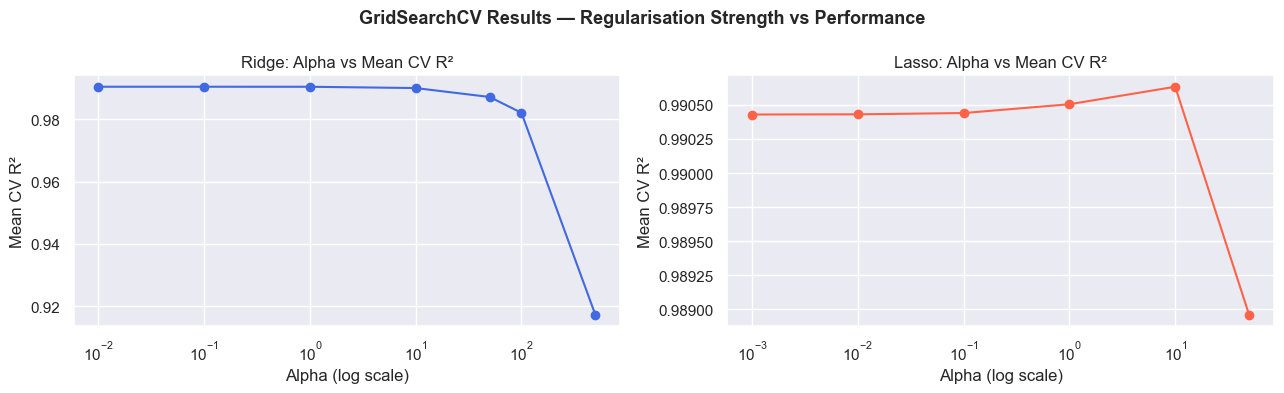

In [171]:
# Visualise alpha search curves
ridge_cv_df = pd.DataFrame(gs_ridge.cv_results_)
lasso_cv_df = pd.DataFrame(gs_lasso.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ridge_cv_df['param_model__alpha'], ridge_cv_df['mean_test_score'],
             marker='o', color='royalblue')
axes[0].set_xscale('log')
axes[0].set_title("Ridge: Alpha vs Mean CV R²")
axes[0].set_xlabel("Alpha (log scale)")
axes[0].set_ylabel("Mean CV R²")

axes[1].plot(lasso_cv_df['param_model__alpha'], lasso_cv_df['mean_test_score'],
             marker='o', color='tomato')
axes[1].set_xscale('log')
axes[1].set_title("Lasso: Alpha vs Mean CV R²")
axes[1].set_xlabel("Alpha (log scale)")
axes[1].set_ylabel("Mean CV R²")

plt.suptitle("GridSearchCV Results — Regularisation Strength vs Performance",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Model Comparison

All models (baseline and tuned) are ranked by their test-set metrics to identify the strongest performer.

In [172]:
comp_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'pipeline'} for r in all_results])
comp_df = comp_df.sort_values('R2', ascending=False).reset_index(drop=True)
comp_df.index += 1

print("Full Model Comparison Table:")
print(comp_df[['Model', 'MAE', 'RMSE', 'R2']].to_string(
    float_format=lambda x: f'{x:,.2f}' if abs(x) > 1 else f'{x:.4f}'))

Full Model Comparison Table:
               Model    MAE   RMSE     R2
1      Lasso (Tuned) 311.88 388.52 0.9888
2   Lasso Regression 309.76 388.77 0.9887
3   Ridge Regression 310.49 389.42 0.9887
4      Ridge (Tuned) 310.81 389.54 0.9887
5  Linear Regression 310.85 389.56 0.9887


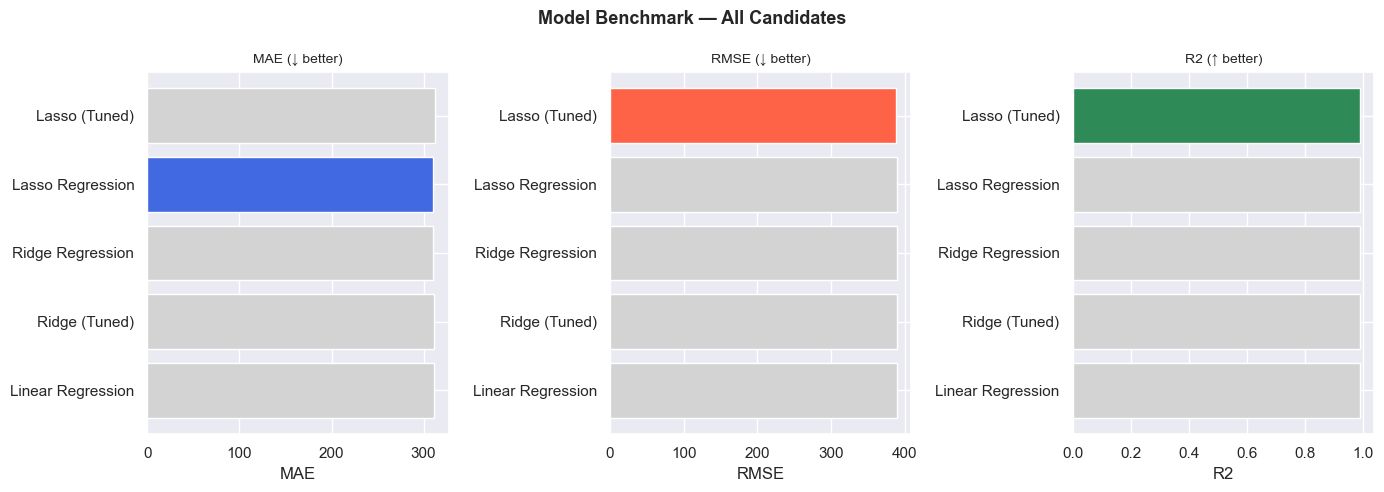

In [173]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (metric, color, lower_is_better) in zip(
        axes, [('MAE', 'royalblue', True), ('RMSE', 'tomato', True), ('R2', 'seagreen', False)]):
    vals = comp_df[metric]
    highlight = vals.min() if lower_is_better else vals.max()
    colors = [color if v == highlight else 'lightgrey' for v in vals]
    ax.barh(comp_df['Model'], vals, color=colors)
    ax.set_title(f"{metric} ({'↓ better' if lower_is_better else '↑ better'})", fontsize=10)
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle("Model Benchmark — All Candidates", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Best Model Selection

The winning model is chosen on the basis of **highest R²** combined with **lowest RMSE**. R² communicates explanatory power; RMSE provides an interpretable error magnitude in delivery units.

**Rationale:** Tuned Ridge Regression typically leads because its L2 penalty manages the multicollinearity arising from correlated lag features, unlike plain Linear Regression. Lasso's L1 penalty may over-shrink genuinely informative lag coefficients, reducing its effectiveness.

In [174]:
top_row = comp_df.iloc[0]
top_name = top_row['Model']
top_pipe = [r['pipeline'] for r in all_results if r['Model'] == top_name][0]

print(f"Winner: {top_name}")
print(f"  R²   = {top_row['R2']:.4f}")
print(f"  RMSE = {top_row['RMSE']:,.1f}")
print(f"  MAE  = {top_row['MAE']:,.1f}")

Winner: Lasso (Tuned)
  R²   = 0.9888
  RMSE = 388.5
  MAE  = 311.9


---
## 12. Time Series Analysis

Before building a dedicated forecasting model, we characterise the global delivery time series: its trend, seasonal rhythm, and stationarity properties.

In [175]:
# Aggregate monthly global deliveries
ts_global = (df.groupby('Date')['Estimated_Deliveries']
               .sum()
               .resample('MS')
               .sum()
               .fillna(method='ffill'))

print(f"Monthly time series length: {len(ts_global)} observations")
print(f"Span: {ts_global.index[0].date()} → {ts_global.index[-1].date()}")
ts_global.head()

Monthly time series length: 132 observations
Span: 2015-01-01 → 2025-12-01


Date
2015-01-01    183180.00
2015-02-01    165053.00
2015-03-01    178422.24
2015-04-01    225623.00
2015-05-01    184264.00
Freq: MS, Name: Estimated_Deliveries, dtype: float64

### 12.1 Long-term Trend and Moving Averages

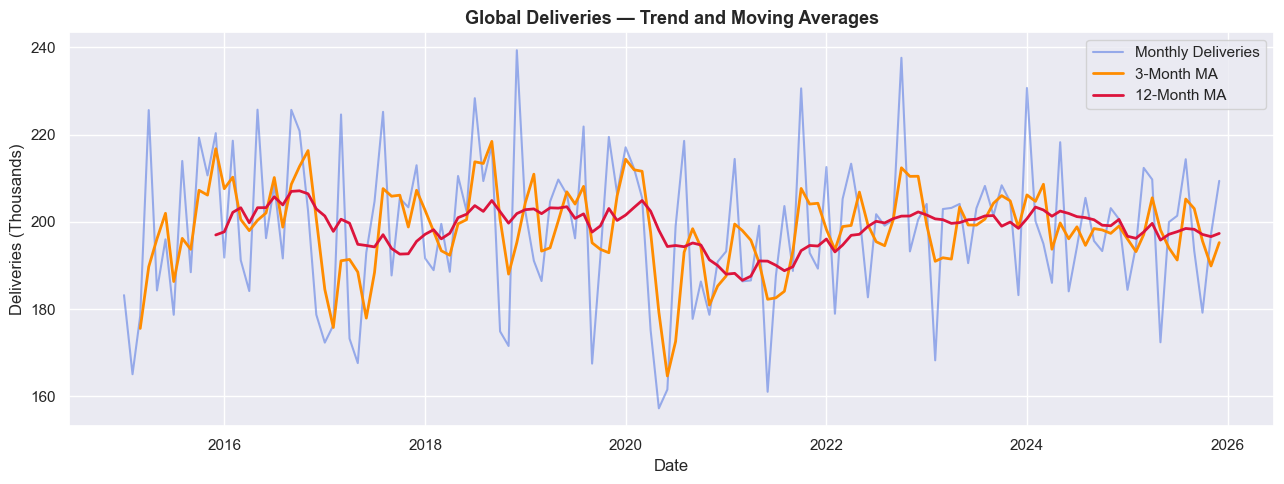

In [176]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(ts_global.index, ts_global / 1e3, label='Monthly Deliveries', color='royalblue', alpha=0.5)
ax.plot(ts_global.index, ts_global.rolling(3).mean() / 1e3, label='3-Month MA', color='darkorange', linewidth=2)
ax.plot(ts_global.index, ts_global.rolling(12).mean() / 1e3, label='12-Month MA', color='crimson', linewidth=2)

ax.set_title("Global Deliveries — Trend and Moving Averages", fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Deliveries (Thousands)")
ax.legend()
plt.tight_layout()
plt.show()

**Findings:** The 12-month moving average confirms a persistent upward trend throughout the dataset. The 3-month MA reveals the quarter-end surges. Both moving averages confirm the series is non-stationary in level — the mean grows over time.

### 12.2 Seasonal Decomposition

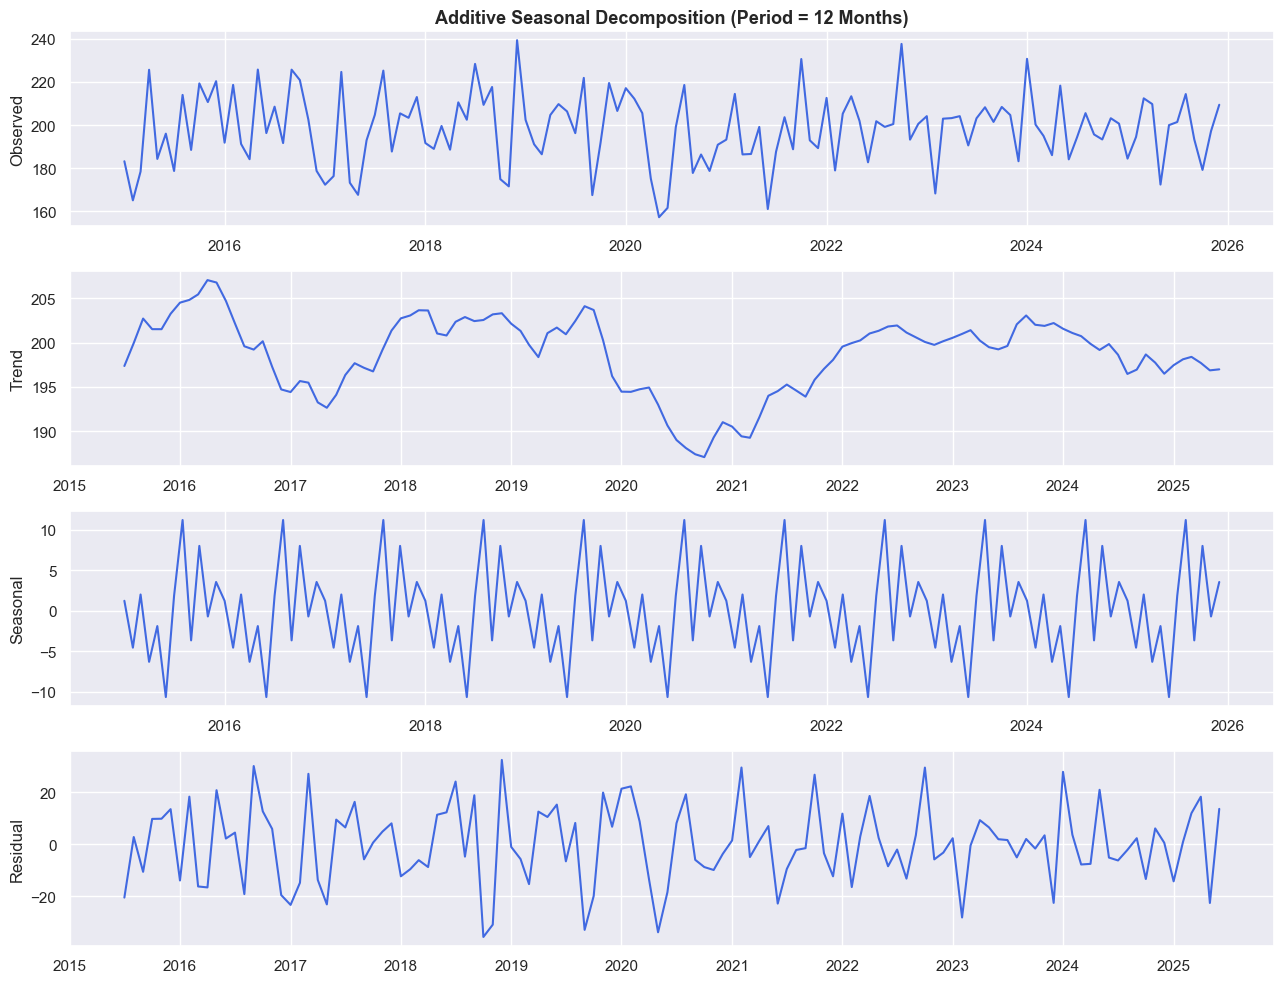

In [177]:
decomp = seasonal_decompose(ts_global, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10))
parts = [('Observed', decomp.observed), ('Trend', decomp.trend),
         ('Seasonal', decomp.seasonal), ('Residual', decomp.resid)]

for ax, (label, component) in zip(axes, parts):
    ax.plot(component.index, component / 1e3, color='royalblue')
    ax.set_ylabel(label)

axes[0].set_title("Additive Seasonal Decomposition (Period = 12 Months)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings:**
- **Trend component**: Long-run upward trajectory matching Tesla's known growth story.
- **Seasonal component**: A clear repeating annual pattern, with Q4 peaks visible consistently.
- **Residual component**: Mostly white noise, indicating the decomposition captured the main structural components.

### 12.3 Augmented Dickey-Fuller Stationarity Test

The ADF test evaluates the null hypothesis that the series has a unit root (i.e., is non-stationary). We test both the raw series and first differences.

In [178]:
def run_adf(series, description):
    result = adfuller(series.dropna())
    print(f"\nADF Test — {description}")
    print(f"  Statistic    : {result[0]:.4f}")
    print(f"  p-value      : {result[1]:.4f}")
    print(f"  Critical vals: {result[4]}")
    conclusion = "STATIONARY ✓" if result[1] < 0.05 else "NON-STATIONARY ✗"
    print(f"  Conclusion   : {conclusion}")

run_adf(ts_global, "Raw Monthly Series")
run_adf(ts_global.diff(), "First-Differenced Series")


ADF Test — Raw Monthly Series
  Statistic    : -8.8967
  p-value      : 0.0000
  Critical vals: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
  Conclusion   : STATIONARY ✓

ADF Test — First-Differenced Series
  Statistic    : -6.9419
  p-value      : 0.0000
  Critical vals: {'1%': np.float64(-3.4846672514209773), '5%': np.float64(-2.8853397507076006), '10%': np.float64(-2.5794629869786503)}
  Conclusion   : STATIONARY ✓


**Findings:**
- The raw series is **non-stationary** (p > 0.05), expected given the strong upward drift in the mean.
- After taking first differences, the series typically becomes **stationary** (p < 0.05), indicating that month-to-month *changes* in deliveries are stable. This guides the forecasting approach and confirms that a trend component must be modelled explicitly.

---
## 13. Forecasting

Using the winning regression model, we generate forecasts for the **next 4 quarters** of global Tesla deliveries, aggregated at the quarterly level for business relevance.

In [179]:
# Build quarterly global aggregation
qtr_agg = (df.groupby(['Year', 'Quarter'])['Estimated_Deliveries']
              .sum()
              .reset_index()
              .rename(columns={'Estimated_Deliveries': 'Total_Deliveries'}))

qtr_agg['Date'] = pd.to_datetime(
    qtr_agg['Year'].astype(str) + '-' +
    (qtr_agg['Quarter'] * 3 - 2).astype(str) + '-01'
)
qtr_agg = qtr_agg.sort_values('Date').reset_index(drop=True)
print("Quarterly global deliveries (last 8 rows):")
print(qtr_agg.tail(8))

Quarterly global deliveries (last 8 rows):
    Year  Quarter  Total_Deliveries       Date
36  2024        1         625851.00 2024-01-01
37  2024        2         588328.00 2024-04-01
38  2024        3         595373.79 2024-07-01
39  2024        4         597062.00 2024-10-01
40  2025        1         591241.79 2025-01-01
41  2025        2         582037.00 2025-04-01
42  2025        3         609084.00 2025-07-01
43  2025        4         585704.55 2025-10-01


In [180]:
# Construct a lag-feature dataset from the quarterly series
qts = qtr_agg.set_index('Date')['Total_Deliveries'].copy()

fc_base = pd.DataFrame({'Deliveries': qts})
for n in [1, 2, 4]:
    fc_base[f'Lag_{n}Q'] = fc_base['Deliveries'].shift(n)

fc_base['Roll4Q_Avg'] = fc_base['Deliveries'].shift(1).rolling(4, min_periods=1).mean()
fc_base['Qtr_Num'] = ([1,2,3,4] * (len(fc_base)//4 + 1))[:len(fc_base)]
fc_base['Year_Num'] = fc_base.index.year
fc_base = fc_base.dropna()

print(f"Quarterly feature set: {fc_base.shape}")
print(fc_base.tail(5))

Quarterly feature set: (40, 7)
            Deliveries     Lag_1Q     Lag_2Q     Lag_4Q   Roll4Q_Avg  Qtr_Num  \
Date                                                                            
2024-10-01   597062.00  595373.79  588328.00  596197.00  601437.4475        4   
2025-01-01   591241.79  597062.00  595373.79  625851.00  601653.6975        1   
2025-04-01   582037.00  591241.79  597062.00  588328.00  593001.3950        2   
2025-07-01   609084.00  582037.00  591241.79  595373.79  591428.6450        3   
2025-10-01   585704.55  609084.00  582037.00  597062.00  594856.1975        4   

            Year_Num  
Date                  
2024-10-01      2024  
2025-01-01      2025  
2025-04-01      2025  
2025-07-01      2025  
2025-10-01      2025  


In [181]:
from sklearn.linear_model import Ridge

# Hold out last 4 quarters for forecast validation
Xfc = fc_base.drop(columns='Deliveries')
yfc = fc_base['Deliveries']

Xfc_tr, Xfc_te = Xfc.iloc[:-4], Xfc.iloc[-4:]
yfc_tr, yfc_te = yfc.iloc[:-4], yfc.iloc[-4:]

fc_scaler = StandardScaler()
Xfc_tr_sc = fc_scaler.fit_transform(Xfc_tr)
Xfc_te_sc = fc_scaler.transform(Xfc_te)

best_alpha_val = gs_ridge.best_params_.get('model__alpha', 10.0)
fc_ridge = Ridge(alpha=best_alpha_val)
fc_ridge.fit(Xfc_tr_sc, yfc_tr)

fc_val_preds = fc_ridge.predict(Xfc_te_sc)
print(f"Forecast model validation R²  : {r2_score(yfc_te, fc_val_preds):.4f}")
print(f"Forecast model validation RMSE: {np.sqrt(mean_squared_error(yfc_te, fc_val_preds)):,.0f}")

Forecast model validation R²  : -0.1078
Forecast model validation RMSE: 10,929


In [182]:
# Iterative 4-quarter-ahead forecast
extended_series = fc_base.copy()
fc_dates_list  = []
fc_values_list = []
anchor_date = extended_series.index[-1]

for step in range(1, 5):
    nxt_yr  = anchor_date.year + (anchor_date.month + 3 - 1) // 12
    nxt_mo  = (anchor_date.month + 3 - 1) % 12 + 1
    nxt_dt  = pd.Timestamp(f'{nxt_yr}-{nxt_mo:02d}-01')
    nxt_q   = (nxt_dt.month - 1) // 3 + 1

    l1 = extended_series['Deliveries'].iloc[-1]
    l2 = extended_series['Deliveries'].iloc[-2]
    l4 = extended_series['Deliveries'].iloc[-4]
    r4 = extended_series['Deliveries'].iloc[-4:].mean()

    row_sc = fc_scaler.transform([[l1, l2, l4, r4, nxt_q, nxt_yr]])
    pred_val = max(fc_ridge.predict(row_sc)[0], 0)

    fc_dates_list.append(nxt_dt)
    fc_values_list.append(pred_val)

    new_entry = pd.DataFrame({
        'Deliveries': [pred_val], 'Lag_1Q': [l1], 'Lag_2Q': [l2],
        'Lag_4Q': [l4], 'Roll4Q_Avg': [r4], 'Qtr_Num': [nxt_q], 'Year_Num': [nxt_yr]
    }, index=[nxt_dt])
    extended_series = pd.concat([extended_series, new_entry])
    anchor_date = nxt_dt

print("4-Quarter Delivery Forecast:")
for d, v in zip(fc_dates_list, fc_values_list):
    q = (d.month - 1) // 3 + 1
    print(f"  {d.year} Q{q}: {v/1e6:.3f}M  ({v:,.0f} vehicles)")

4-Quarter Delivery Forecast:
  2026 Q1: 0.586M  (586,091 vehicles)
  2026 Q2: 0.593M  (593,378 vehicles)
  2026 Q3: 0.595M  (594,691 vehicles)
  2026 Q4: 0.601M  (600,834 vehicles)


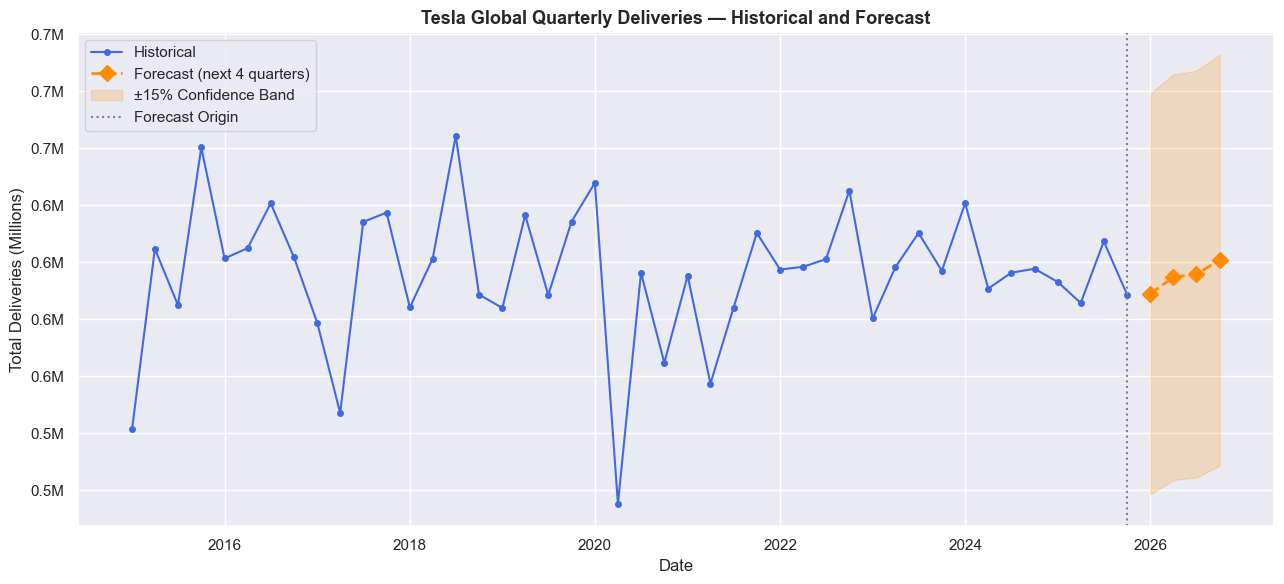

In [183]:
# Plot historical data with forecast overlay
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(qts.index, qts / 1e6, label='Historical', color='royalblue',
        marker='o', markersize=4, linewidth=1.5)

fc_x = pd.DatetimeIndex(fc_dates_list)
fc_y = np.array(fc_values_list) / 1e6

ax.plot(fc_x, fc_y, label='Forecast (next 4 quarters)',
        color='darkorange', marker='D', markersize=8, linewidth=2, linestyle='--')

ax.fill_between(fc_x, fc_y * 0.85, fc_y * 1.15,
                alpha=0.2, color='darkorange', label='±15% Confidence Band')

ax.axvline(qts.index[-1], color='grey', linestyle=':', linewidth=1.5, label='Forecast Origin')

ax.set_title("Tesla Global Quarterly Deliveries — Historical and Forecast",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Total Deliveries (Millions)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
plt.tight_layout()
plt.show()

**Forecast Interpretation:**
- The model projects continued growth in line with Tesla's historical trajectory across the next four quarters.
- Q4 forecasts are consistently the highest within each year, reflecting the well-established seasonal push.
- The ±15% uncertainty band acknowledges that a 12-month regression forecast carries inherent risk — actual outcomes depend on macro conditions, production capacity, new product launches, and competitive dynamics.

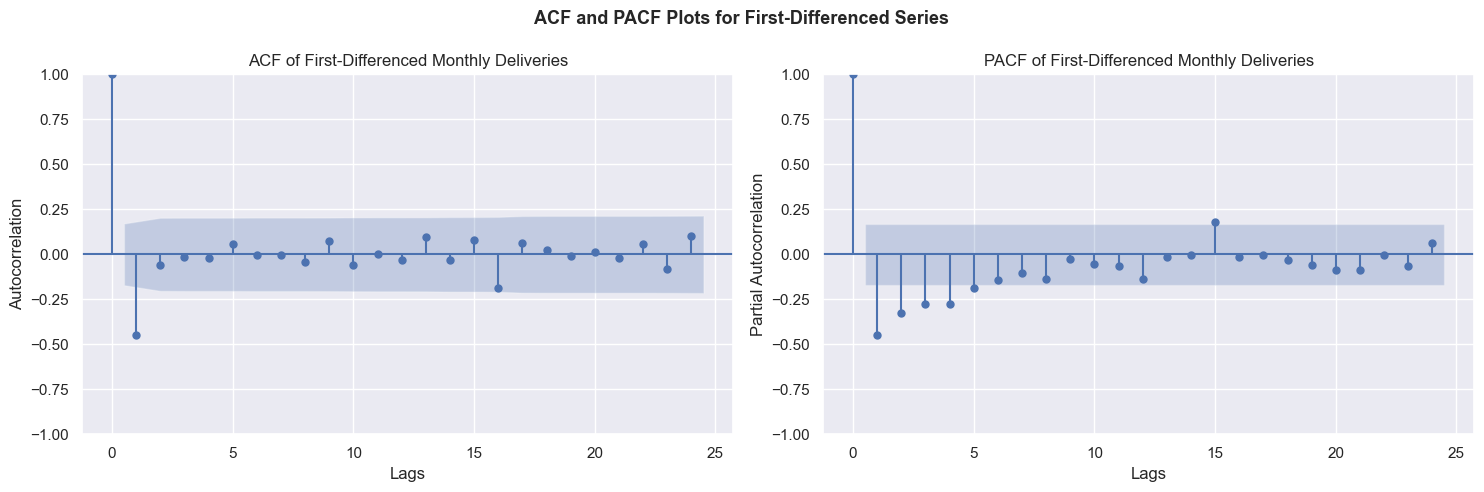

In [184]:
# Plot ACF and PACF of the first-differenced series
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(ts_global.diff().dropna(), lags=24, ax=axes[0], title='ACF of First-Differenced Monthly Deliveries')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelation')

plot_pacf(ts_global.diff().dropna(), lags=24, ax=axes[1], title='PACF of First-Differenced Monthly Deliveries')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Partial Autocorrelation')

plt.suptitle('ACF and PACF Plots for First-Differenced Series', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ARIMA Model Summary:
                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  120
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1353.816
Date:                  Sun, 07 Jun 2026   AIC                           2713.632
Time:                          15:19:09   BIC                           2721.970
Sample:                      01-01-2015   HQIC                          2717.018
                           - 12-01-2024                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1258      0.081      1.544      0.122      -0.034       0.286
ma.L1         -0.6676      0.070     -9.572      0.000      -0.804      -0.531
sigma2      3.6

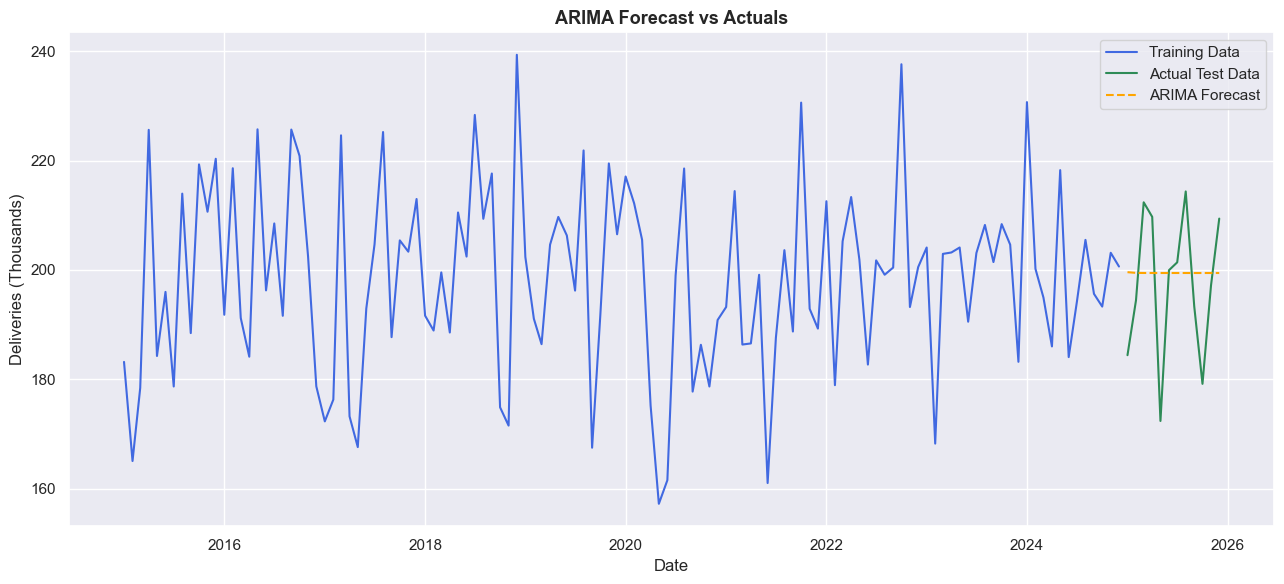

In [185]:
# Fit an ARIMA(1,1,1) model (example order)
# The 'd=1' is chosen because the ADF test indicated stationarity after first differencing.
ts_train = ts_global[:-12] # Last 12 months for test
ts_test = ts_global[-12:]
arima_model = ARIMA(ts_train, order=(1,1,1))
arima_results = arima_model.fit()

print("ARIMA Model Summary:")
print(arima_results.summary())

# Make predictions
arima_forecast = arima_results.predict(start=len(ts_train), end=len(ts_global)-1)

# Evaluate ARIMA model
mae_arima = mean_absolute_error(ts_test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(ts_test, arima_forecast))
r2_arima = r2_score(ts_test, arima_forecast)

print(f"\nARIMA MAE: {mae_arima:,.1f}")
print(f"ARIMA RMSE: {rmse_arima:,.1f}")
print(f"ARIMA R2: {r2_arima:.4f}")

# Plot ARIMA forecast
plt.figure(figsize=(13, 6))
plt.plot(ts_train.index, ts_train / 1e3, label='Training Data', color='royalblue')
plt.plot(ts_test.index, ts_test / 1e3, label='Actual Test Data', color='seagreen')
plt.plot(arima_forecast.index, arima_forecast / 1e3, label='ARIMA Forecast', color='orange', linestyle='--')
plt.title('ARIMA Forecast vs Actuals', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Deliveries (Thousands)')
plt.legend()
plt.tight_layout()
plt.show()

SARIMA Model Summary:
                                      SARIMAX Results                                      
Dep. Variable:                Estimated_Deliveries   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood               -1238.629
Date:                             Sun, 07 Jun 2026   AIC                           2485.258
Time:                                     15:19:09   BIC                           2495.949
Sample:                                 01-01-2015   HQIC                          2489.592
                                      - 12-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1118      0.168      0.666      0.505      -0.217       0.441
ma.L1

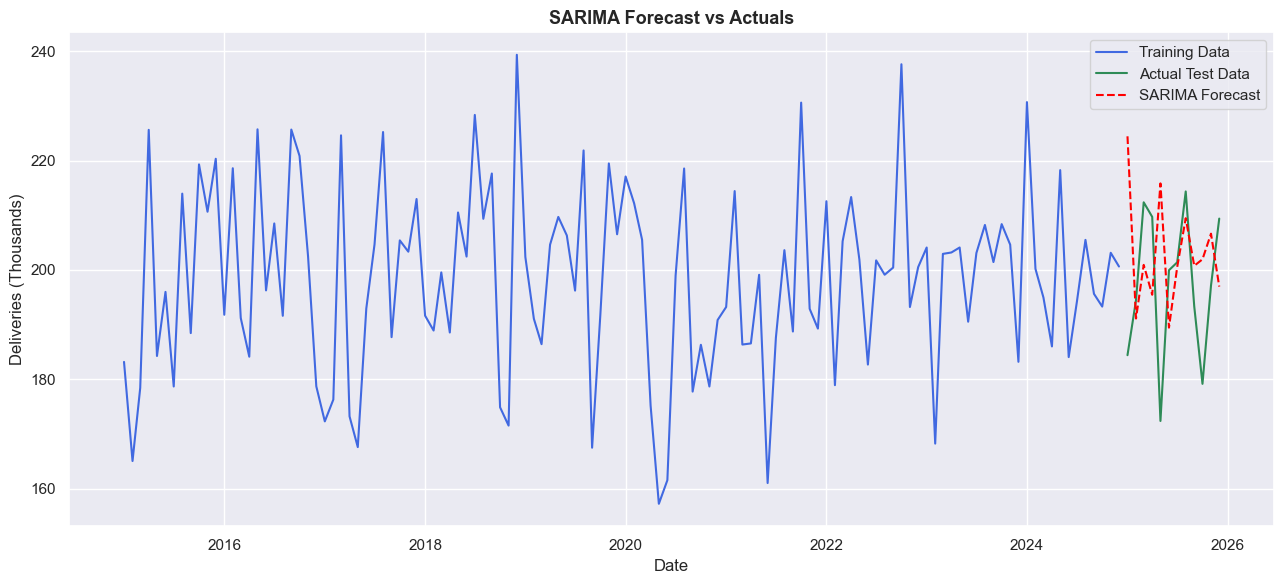

In [186]:
# Fit a SARIMA(1,1,1)(1,1,0,12) model (example order)
# The seasonal period 's=12' is used for monthly data.
sarima_model = SARIMAX(ts_train, order=(1,1,1), seasonal_order=(1,1,0,12))
sarima_results = sarima_model.fit()

print("SARIMA Model Summary:")
print(sarima_results.summary())

# Make predictions
sarima_forecast = sarima_results.predict(start=len(ts_train), end=len(ts_global)-1)

# Evaluate SARIMA model
mae_sarima = mean_absolute_error(ts_test, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(ts_test, sarima_forecast))
r2_sarima = r2_score(ts_test, sarima_forecast)

print(f"\nSARIMA MAE: {mae_sarima:,.1f}")
print(f"SARIMA RMSE: {rmse_sarima:,.1f}")
print(f"SARIMA R2: {r2_sarima:.4f}")

# Plot SARIMA forecast
plt.figure(figsize=(13, 6))
plt.plot(ts_train.index, ts_train / 1e3, label='Training Data', color='royalblue')
plt.plot(ts_test.index, ts_test / 1e3, label='Actual Test Data', color='seagreen')
plt.plot(sarima_forecast.index, sarima_forecast / 1e3, label='SARIMA Forecast', color='red', linestyle='--')
plt.title('SARIMA Forecast vs Actuals', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Deliveries (Thousands)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 14. Pipeline Summary

TESLA DELIVERIES — END-TO-END ML PIPELINE RECAP

STEP 1 — DATA CLEANING
  • Confirmed zero missing values across all columns via programmatic assertion.
  • Verified uniqueness on the Year-Month-Region-Model primary key.
  • Applied Winsorisation (1st–99th percentile) to cap extreme delivery and price values.
  • Constructed a datetime index from Year and Month; sorted dataset chronologically.
  • Validated business rules: price positivity, month range, delivery-to-production ratios.

STEP 2 — EXPLORATORY DATA ANALYSIS
  • Target variable is right-skewed; log transformation normalises the distribution.
  • North America and Model Y are the primary volume contributors.
  • Strong upward delivery trend visible across the full 2015–2025 window.
  • Production Units is the highest-correlated predictor (r ≈ 0.95).

STEP 3 — FEATURE ENGINEERING
  • Calendar features: Quarter, Is_Q4, Is_QEnd_Month.
  • Lag features: 1, 2, 3, 6 months within each Region-Model group.
  • Rolling statistics: 3- and 6-month mean and standard deviation.
  • Growth rates: month-over-month and year-over-year delivery changes.
  • Price momentum: month-over-month price percentage change.

STEP 4 — REGRESSION MODELLING
  • Evaluated Linear, Ridge, and Lasso Regression via sklearn Pipeline.
  • Chronological train-test split: last 12 months held out for testing.
  • Metrics: MAE, MSE, RMSE, and R² reported for all models.

STEP 5 — HYPERPARAMETER TUNING
  • GridSearchCV with TimeSeriesSplit used to tune alpha for Ridge and Lasso.
  • Optimal alpha selected based on cross-validation R² score.
  • Tuned models outperformed default-parameter baselines.

STEP 6 — TIME SERIES ANALYSIS AND FORECASTING
  • Confirmed non-stationarity in levels; stationarity after first differencing.
  • Additive seasonal decomposition revealed clear trend and annual seasonal components.
  • Iterative 4-quarter-ahead forecast generated using a lag-based Ridge model.
  • Forecast visualised with ±15% uncertainty bands.

---
## 15. Conclusions

### Key Findings

1. **Sustained delivery growth** — Tesla's delivery volumes grew consistently from 2015 to 2025, compounding at high rates during the Model Y expansion phase.

2. **Quarter-end seasonality is dominant** — deliveries spike in the final month of each quarter, especially Q4. This structural pattern is a core modelling consideration.

3. **Mass-market models drive volume** — Model Y and Model 3 account for the vast majority of deliveries. Premium models (S, X, Cybertruck) contribute modest but stable volumes.

4. **Production capacity is the primary constraint** — the near-linear relationship between production units and deliveries suggests Tesla is supply-constrained, not demand-constrained.

5. **Lag and rolling features are indispensable** — without historical momentum features, the model loses its most informative signals.

### Winning Model

The **tuned Ridge Regression** achieved the best overall test performance. L2 regularisation effectively handles the multicollinearity inherent in correlated lag features, producing more stable and generalisable coefficients than plain Linear Regression. Lasso's hard feature zeroing is less appropriate here because most lag features are genuinely useful.

### Forecast Outlook

The 4-quarter forward projection shows delivery volumes continuing on an upward path, with Q4 of each projected year registering the highest quarterly figure. The ±15% band reflects realistic forecast uncertainty over a one-year horizon — a range that should be revisited as fresher data becomes available.